# Notebook to study the relation between the isotropic-equivalent energies of the prompt emission observed from an on and an off-axis point of view.

Packages used for this part of the MSc research project:

In [1]:
import numpy as np 
import scipy as sc 
import matplotlib.pyplot as plt
import astropy.units as u
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_4059492/4110105686.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  import scipy as sc


## Firstly, I assume a top-hat jet. Therefore, following the derivations presented in the MSc thesis, I introduce the terms that are in the integrand of the numerator and denominator of the expression derived in the MSc thesis (see the Chapter 2 about the methodology).

In [2]:
# Defining the jet speed as a function of the jet Lorentz factor:
def gammatobeta(gamma):
    return np.sqrt(1 - (gamma**(-2)))

#For the cosine of the angle between the direction of motion of the emitting material and the observer line of sight:
def coschi(thetav,theta,phi):
    return np.cos(thetav)*np.cos(theta) +np.sin(thetav)*np.sin(theta)*np.cos(phi)

#Defining the Doppler factor:
def Doppler(gamma,thetav, theta,phi):
    return 1/(gamma*(1-gammatobeta(gamma)*coschi(thetav,theta,phi)))

Next, we can proceed to directly evaluate the expression derived for a top-hat jet by using different values of the bulk Lorentz factor of the jet, viewing angles and setting a half-opening angle of the jet for each plot:

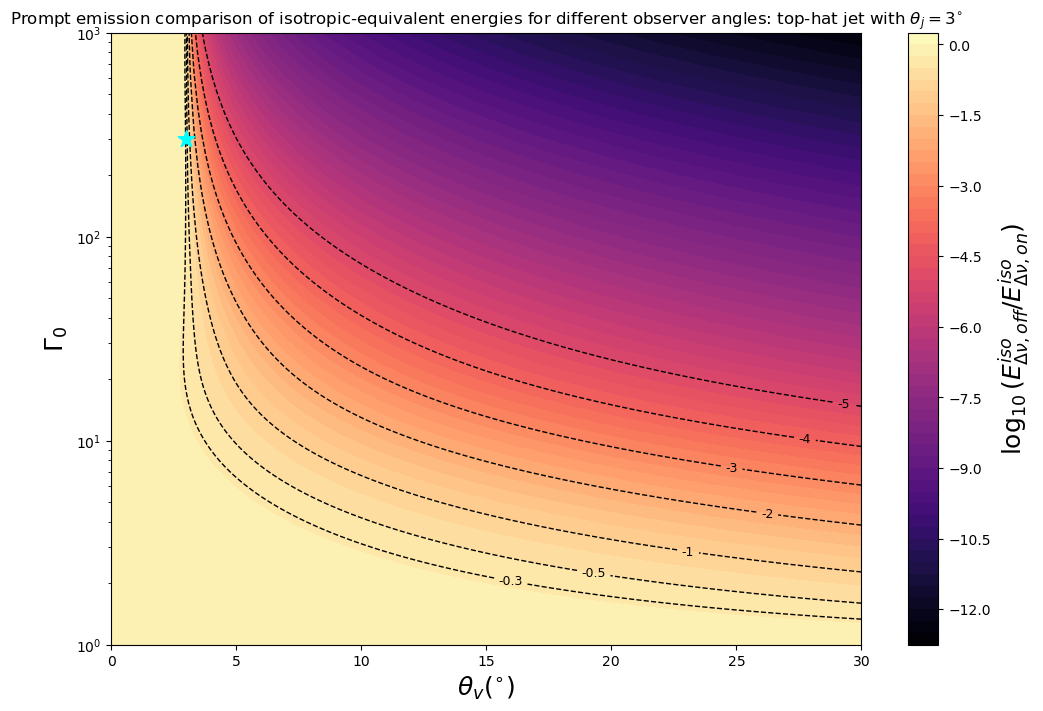

In [3]:
#Number of points:
Ng=250 #Gamma points
Np=200 #Viewing angle points
Nint=200 # Integration points
#Note that increasing these numbers the computation time will increase significantly.

#Gamma values:
GammaVal=np.logspace(0,3,Ng)
#Viewing angle values:
VVAL=np.linspace(0,30,Np) #in degrees
VVALM, GammaVM=np.meshgrid(VVAL, GammaVal) # The shape of this variable is (Np, Ng)
# Note that we need to define this meshgrid because of the need of evaluating the ratio of isotropic-equivalent energies on and off-axis
# for all the possible combinations of Gamma and viewing angle.


#Defining the variables over which we are going to integrate:
phiint=np.linspace(0,2*np.pi,Nint) #Azimuthal angle in radians
#ThetaJet=np.array([3, 5, 7]) # The code is capable of plotting several figures for various values of theta jet (in degrees)
ThetaJet=np.array([3]) #Polar angle in degrees

#Now, creating the figure that represent the prompt emission isotropic-equivalent energies
# on and off-axis ratio derived in the MSc thesis for a top-hat jet:
for i in range(0,len(ThetaJet)): #This creates as many figures as theta jet provided
    #Defining the variables for our integrated Eiso off and on axis:
    Eoff=np.zeros((Ng,Np)) #First index represent Gammas and second index viewing angles.
    Eon=np.zeros((Ng)) #This only depends on gamma, thetav=0.
    #Now, for the polar angle integration parameter:
    thetaInt=np.linspace(0,np.radians(ThetaJet[i]),Nint)
    #Creating the grid over which we are going to integrate:
    Thetagrid, Phigrid = np.meshgrid(thetaInt, phiint, indexing='ij') #shape of this variable (Nint, Nint)
    #Computing the sin of the integral first:
    sinint=np.sin(Thetagrid) #Shape (Nint, Nint)

    #Now, making first the loop of the integration for gamma:
    for GammaInd, Gamma in enumerate(GammaVal):
        #First, we want to compute the Doppler factor for all the viewing angle values at once
        #But the viewing angle parameter variable shape is (Np), and since we want to integrate afterwards over 
        #theta and phi, we need to work with variables with three indeces, i.e.
        # shape (N_i , N_j, N_k), to do so:
        VarrCalc=VVAL[:, None, None] #Shape of this now: (Np,1,1)
        #Similarly, for the integration variables:
        ThetagridCalc=Thetagrid[None,:,:] #Shape of this now: (1,Nint,Nint)
        PhigridCalc=Phigrid[None,:,:] #Shape of this now: (1,Nint,Nint)
        #Now, calculating all the Doppler factors at once for the off-axis case and for each Gamma:
        Doff=Doppler(Gamma,np.radians(VarrCalc),ThetagridCalc,PhigridCalc) #shape of this: (Np,Nint,Nint)

        #Now, for the integrand of the off-axis integral:
        integrandoff=sinint[None,:,:]*(Doff**3) #Using the trick in the sine function to match the shapes. Now: (Np, Nint,Nint)
        #Note that for the ratio in integrated fluxes:
        #integrandoff=sinint[None,:,:]*(Doff**4) 

        #Integrating, first over theta and then over phi:
        Eofftheta=sc.integrate.simps(integrandoff,thetaInt, axis=1) #axis=1 to integrate over the second array, shape after this: (Np, Nint)
        EoffVval=sc.integrate.simps(Eofftheta,phiint, axis=1) #Shape after this: (Np), but this is only for one gamma value 
                                                                # (that is what the loop is doing), so:
        Eoff[GammaInd,:]=EoffVval #Shape after the whole loop =(Ng, Np)

        #Now, the same for the on axis case (simpler since viewing angle =0). We do not need the trick of the shapes for this:
        Don=Doppler(Gamma,0,Thetagrid,Phigrid) #shape=(Nint,Nint)
        #For the integrand:
        integrandon=sinint*(Don**3) #Shape=(Nint,Nint)
        #Note that for the ratio in integrated fluxes:
        #integrandon=sinint*(Don**4)

        #So, integrating:
        Eontheta=sc.integrate.simps(integrandon,thetaInt,axis=0)
        EonScalar=sc.integrate.simps(Eontheta, phiint, axis=0) #This return a scalar since viewing angle = 0
        Eon[GammaInd]=EonScalar #Shape after the whole loop =(Ng)
    
    #After this loop we have Eoff with shape (Ng, Np) for all the values of gamma and viewing angles and 
    #Eon with shape (Ng). Then, calculating their ratio now:
    Eongrid=Eon[:, None] #Now shape (Ng,1)

    #Calculating the ratio:
    EisoRat=np.log10(Eoff/Eongrid)
    EisoRat_masked = np.ma.masked_invalid(EisoRat)
    #Levels of the contour I will mark:
    levels_to_mark = [-0.3,-0.5,-1,-2,-3,-4,-5]
    levels_to_mark=sorted(levels_to_mark)
    #Finally, plotting the results for each theta jet:
    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    cs = ax.contourf(VVALM, GammaVM, EisoRat, levels=60, cmap=mpl.colormaps['magma'])
    #Plotting the lines of constant ratio:
    colors = ['black'] * len(levels_to_mark)
    cs_lines = ax.contour(VVALM, GammaVM, EisoRat_masked,
                     levels=levels_to_mark,
                     colors='black', linewidths=1.0, linestyles='--')
    # Building labels for each dashed line and putting them on the contours
    fmt = {lvl: rf'{lvl}' for lvl in levels_to_mark}
    ax.clabel(cs_lines, fmt=fmt, inline=True, fontsize=9)
    #Some lines that may be useful for the physical interpretation of this figure:
    #ax.plot(np.degrees(1/GammaVal),GammaVal, color='green',linewidth=1.5, linestyle='--')
    #ax.hlines(1/np.radians(10),VVAL.min(),VVAL.max(),color='blue',linewidth=1.5, linestyle='--')
    #ax.vlines(ThetaJet[i],GammaVal.min(), GammaVal.max(),color='blue',linewidth=1.5, linestyle='--')
    ax.scatter(ThetaJet*1,300, s=160, marker='*',zorder=2, c='cyan')
    ax.set_xlabel(rf'$\theta_v (^{{\circ}})$', fontsize=18)
    ax.set_ylabel(rf'$\Gamma_0$', fontsize=18)
    ax.set_title(rf'Prompt emission comparison of isotropic-equivalent energies for different observer angles: top-hat jet with $\theta_j = {ThetaJet[i]}^{{\circ}}$')
    ax.set_yscale('log')
    cbar=fig.colorbar(cs)
    cbar.set_label(rf'$\log_{{10}}(E^{{iso}}_{{\Delta \nu, off}} / E^{{iso}}_{{\Delta \nu, on}})$', fontsize=18)
    ax.set_ylim(GammaVal.min(), GammaVal.max())
    ax.set_xlim(VVAL.min(), VVAL.max())
    plt.show()



## Secondly, assuming a Gaussian structured jet:

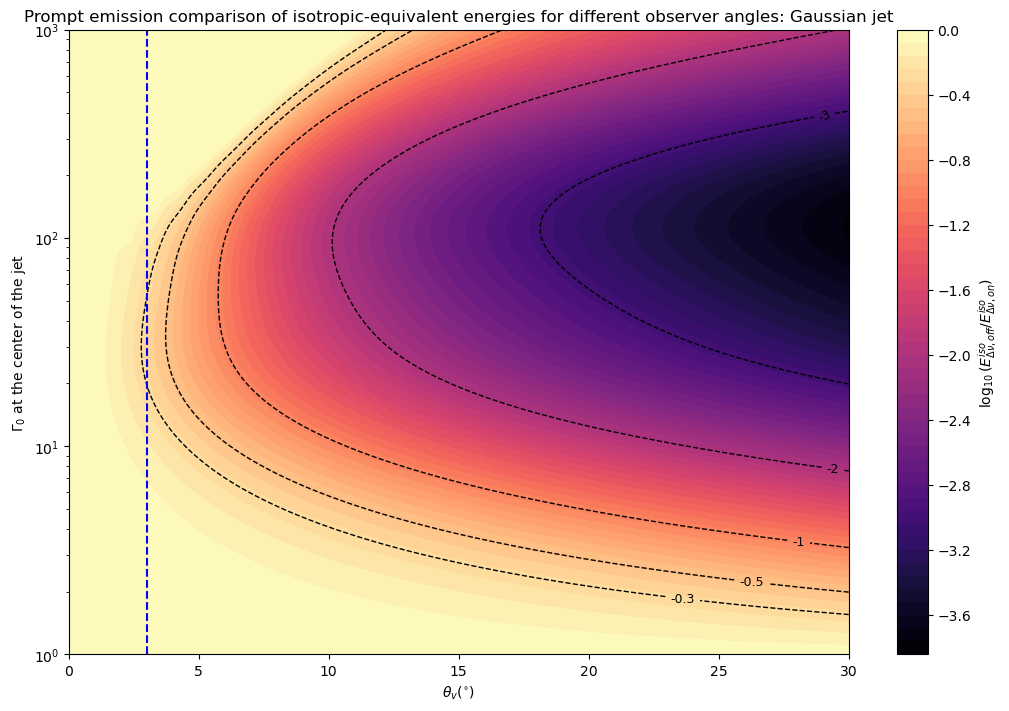

In [4]:
# Defining the jet speed as a function of the jet Lorentz factor:
def gammatobeta(gamma):
    return np.sqrt(1 - (gamma**(-2)))

#For the cosine of the angle between the direction of motion of the emitting material and the observer line of sight:
def coschi(thetav,theta,phi):
    return np.cos(thetav)*np.cos(theta) +np.sin(thetav)*np.sin(theta)*np.cos(phi)

#Defining the Doppler factor:
def Doppler(gamma,thetav, theta,phi):
    return 1/(gamma*(1-gammatobeta(gamma)*coschi(thetav,theta,phi)))

#Gamma of the jet distribution (Gaussian function) (the last term is a technicality used in REDBACK codes and I use here also for consistency):
def GammaGauss(gamma0,theta,thetac):
    return (gamma0 - 1)*np.exp(-0.5*((theta/thetac)**2)) + 1.000000000000001


#Similarly as above:
thetajet=3 #In degrees
thetaedge=90 #In degrees

#Number of points:
Ng=300 #Gamma0 points
Np=250 #Viewing angle points
Nint=200 # Integration points

#Gamma values at the center of the jet:
GammaVal=np.logspace(0,3,Ng)
#Viewing angle factor values:
VVAL=np.linspace(0,30,Np) #degrees
VVALM, GammaVM=np.meshgrid(VVAL, GammaVal) #shapes of this (Np, Ng)

#Defining the variables over which we are going to integrate:
phiint=np.linspace(0,2*np.pi,Nint) #Jet azimuthal angle in radians

#Defining the variables for our integrated Eiso off and on axis:
Eoff=np.zeros((Ng,Np)) #First index gammas and second index viewing angles.
Eon=np.zeros((Ng)) #This only depends on gamma, viewing angle = 0.
#Now, for the polar angle integration parameter:
thetaInt=np.linspace(0,np.deg2rad(thetaedge),Nint)
#Creating the grid over which we are going to integrate:
Thetagrid, Phigrid = np.meshgrid(thetaInt, phiint, indexing='ij') #shapes of this (Nint, Nint)
#Computing the sin of the integral first:
sinint=np.sin(Thetagrid) #Shape (Nint, Nint)
# Now, creating the figure that represent the prompt emission isotropic-equivalent energies
# on and off-axis ratio derived in the MSc thesis for a Gaussian structured jet:
# I do not add comments in here because the computations are completely equivalent to the ones presented above:
for GammaInd, Gamma in enumerate(GammaVal):
    VarrCalc=VVAL[:, None, None] #Shape of this now: (Np,1,1)
    ThetagridCalc=Thetagrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    PhigridCalc=Phigrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    Doff=Doppler(GammaGauss(Gamma,ThetagridCalc,np.deg2rad(thetajet)),np.deg2rad(VarrCalc),ThetagridCalc,PhigridCalc) #shape of this: (Np,Nint,Nint)
    
    #For the new term from the Gaussian structured jets (see MSc thesis Chapter 2):
    NToff=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #Shape of this now: (1,Nint,Nint)

    #Now, for the integrand of the off-axis integral:
    integrandoff=sinint[None,:,:]*(Doff**3)*(NToff[None,:,:]**-1) #Now: (Np, Nint,Nint)
    #Note that for the ratio in integrated fluxes:
    #integrandoff=sinint[None,:,:]*(Doff**4)*(NToff[None,:,:]**-1)


    #Integrating, first over theta and then over phi:
    Eofftheta=sc.integrate.simps(integrandoff,thetaInt, axis=1) #axis=1 to integrate over the second array, shape after this: (Np, Nint)
    EoffVval=sc.integrate.simps(Eofftheta,phiint, axis=1) #Shape after this: (Np), but this is only for the first gamma, so:
    Eoff[GammaInd,:]=EoffVval

    #For the new term from the Gaussian structured jets (see MSc thesis Chapter 2):
    NTon=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #shape=(Nint,Nint)
    Don=Doppler(GammaGauss(Gamma,Thetagrid,np.deg2rad(thetajet)),0,Thetagrid,Phigrid) #shape=(Nint,Nint)
    #For the integrand:
    integrandon=sinint*(Don**3)*(NTon**-1) #Shape=(Nint,Nint)
    #Note that for the ratio in integrated fluxes:
    #integrandon=sinint*(Don**4)*(NTon**-1) #Shape=(Nint,Nint)

    #Integrating:
    Eontheta=sc.integrate.simps(integrandon,thetaInt,axis=0)
    EonScalar=sc.integrate.simps(Eontheta, phiint, axis=0)
    Eon[GammaInd]=EonScalar #Shape after the whole loop =(Ng)

    #After this loop we have Eoff with shape (Ng, Np) for all the values of gamma and viewing angles and 
    #Eon with shape (Ng). Then, calculating their ratio:
    Eongrid=Eon[:, None] #Now, shape (Ng,1)

    #Calculating the ratio:
    EisoRat=np.log10(Eoff/Eongrid)
    EisoRat_masked = np.ma.masked_invalid(EisoRat)
    EisoRat[EisoRat > 0] = 0 #Since the ratio cannot be greater than 1, we set all the values greater than 0 to 0 
                            #(since we are in log10 space). This is caused by numerical instabilities when 
                            #theta edje is very large compared to thetajet.
    #Levels of the contour I will mark:
    levels_to_mark = [-0.3,-0.5,-1,-2,-3,-4,-5]
    levels_to_mark=sorted(levels_to_mark)


#Finally, plotting the results for each theta jet:
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
cs = ax.contourf(VVALM, GammaVM, EisoRat, levels=60, cmap=mpl.colormaps['magma'])
colors = ['black'] * len(levels_to_mark)
cs_lines = ax.contour(VVALM, GammaVM, EisoRat_masked,
                     levels=levels_to_mark,
                     colors='black', linewidths=1.0, linestyles='--')
fmt = {lvl: rf'{lvl}' for lvl in levels_to_mark}
ax.clabel(cs_lines, fmt=fmt, inline=True, fontsize=9)
#ax.plot(np.degrees(1/GammaVal),GammaVal, color='green',linewidth=1.5, linestyle='--')
#ax.hlines(1/np.radians(10),VVAL.min(),VVAL.max(),color='blue',linewidth=1.5, linestyle='--')
ax.vlines(thetajet,GammaVal.min(), GammaVal.max(),color='blue',linewidth=1.5, linestyle='--')
ax.set_xlabel(rf'$\theta_v (^{{\circ}})$')
ax.set_ylabel(rf'$\Gamma_0$ at the center of the jet')
ax.set_title(rf'Prompt emission comparison of isotropic-equivalent energies for different observer angles: Gaussian jet')
ax.set_yscale('log')
fig.colorbar(cs, label=rf'$\log_{{10}}(E^{{iso}}_{{\Delta \nu, off}} / E^{{iso}}_{{\Delta \nu, on}})$')
ax.set_ylim(GammaVal.min(), GammaVal.max())
ax.set_xlim(VVAL.min(), VVAL.max())
plt.show()  